In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

### Part (a)

The given probability density function (pdf) is:
$$
p(x_i; \mu, \sigma^2) = \frac{1}{x_i \sqrt{2\pi\sigma^2}} \exp\left(-\frac{(\ln x_i - \mu)^2}{2\sigma^2}\right)
$$

It is given that the samples are $iid$(independent and identically distributed), so we can express the joint pdf or the Likelihood function as the product of individual pdf\textit{s} of each of these observations. If there are \( n \) observations, the joint pdf can be written as:

$$
p(x_1, ..., x_n; \mu, \sigma^2) = \prod_{i=1}^{n} p(x_i; \mu, \sigma^2)
$$

Substituting the expression for $p(x_i; \mu, \sigma^2)$, we get:

$$
p(x_1, ..., x_n; \mu, \sigma^2) = \prod_{i=1}^{n} \frac{1}{x_i \sqrt{2\pi\sigma^2}} \exp\left(-\frac{(\ln x_i - \mu)^2}{2\sigma^2}\right)
$$
This is our likelihood function.
$$
L(\mathbf{\theta}; x_1, ..., x_n) = \prod_{i=1}^{n} \frac{1}{x_i \sqrt{2\pi\sigma^2}} \exp\left(-\frac{(\ln x_i - \mu)^2}{2\sigma^2}\right)
$$

### Part (b)

Taking the natural logarithm of the joint pdf, we get the log-likelihood function $\ell(\theta; x_1, ..., x_n)$:
\begin{align*}
    \ell(\theta; x_1, ..., x_n) &= \ln L(\theta; x_1, ..., x_n) \\
    &= \ln \left[ \prod_{i=1}^{n} \frac{1}{x_i \sqrt{2\pi\sigma^2}} \exp\left(-\frac{(\ln x_i - \mu)^2}{2\sigma^2}\right)\right] \\  
    &= \sum_{i=1}^{n} \ln \left[\frac{1}{x_i \sqrt{2\pi\sigma^2}} \exp\left(-\frac{(\ln x_i - \mu)^2}{2\sigma^2}\right)\right]\quad (\text{using } \ln(ABC...) = \ln A +\ln B + \ln C + ...)\\
    &= \sum_{i=1}^{n} \left[\ln{\frac{1}{x_i \sqrt{2\pi\sigma^2}}} + \ln{\exp\left(-\frac{(\ln x_i - \mu)^2}{2\sigma^2}\right)}\right]\\
    &= \sum_{i=1}^{n} \left[-\ln{{x_i \sqrt{2\pi\sigma^2}}} + \ln{\exp\left(-\frac{(\ln x_i - \mu)^2}{2\sigma^2}\right)}\right]\\
    &= \sum_{i=1}^{n} \left[ -\ln(x_i) - \frac{1}{2} \ln(2\pi\sigma^2) - \frac{(\ln x_i - \mu)^2}{2\sigma^2} \right]\\
    &= \sum_{i=1}^{n} \left[ -\ln(x_i) - \frac{1}{2} \ln(2\pi) -\frac{1}{2} \ln(\sigma^2)- \frac{(\ln x_i - \mu)^2}{2\sigma^2} \right]\\
    &=  - \frac{n}{2} \ln(2\pi)- \frac{n}{2} \ln(\sigma^2) -\dfrac{1}{2\sigma^2}\sum_{i=1}^{n}\left[\ln{(x_i)}-\mu\right]^2-\sum_{i=1}^{n} \ln(x_i)
\end{align*}
Here, I have used the properties of log and the fact that when a constant term is summed n times, the result can be obtained by multiplying it by n. Hence, we have:
$$
\ell(\theta; x_1, ..., x_n) =  - \frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) -\frac{1}{2\sigma^2}\sum_{i=1}^{n}\left[\ln{(x_i)}-\mu\right]^2 -\sum_{i=1}^{n} \ln(x_i)
$$

### Part (c)

The final expression in last part represents the log-likelihood function for the given data and parameters. To find the maximum likelihood estimates (MLEs) of $\mu$ and $\sigma^2$, we can differentiate this expression with respect to $\mu$ and $\sigma^2$, set the derivatives equal to zero, and solve for $\mu$ and $\sigma^2$.

To find $\hat{\mu}$, differentiating $l$ with respect to $\mu$, we get:
\begin{align*}
    \frac{\partial l}{\partial \mu} &= \frac{1}{\sigma^2} \sum_{i=1}^{n} \left[\ln{(x_i)} - \mu\right] 
\end{align*}
Setting this equal to zero:
$$
    \frac{1}{\sigma^2} \sum_{i=1}^{n} \left[\ln{(x_i)} - \hat{\mu}\right] = 0 \\
    \implies \sum_{i=1}^{n} \left[\ln{(x_i)} \right] - n\hat{\mu} =0
$$
$$
    \implies \hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} \ln{(x_i)} 
$$
To find $\hat{\sigma}^2$, we can differentiate $l$ with respect to $\sigma^2$: 
\begin{align*}
    \frac{\partial l}{\partial (\sigma^2)} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^{n} \left[\ln{(x_i)} - \mu\right]^2
\end{align*}

Setting this equal to zero:
\begin{align*}
-\frac{n}{2\hat{\sigma}^2} + \frac{1}{2(\hat{\sigma}^2)^2} \sum_{i=1}^{n} \left[\ln{(x_i)} - \hat{\mu}\right]^2 = 0 
\end{align*}
On rearranging, we have: 
$$
\quad n = \frac{1}{\hat{\sigma}^2} \sum_{i=1}^{n} \left[\ln{(x_i)} - \hat{\mu}\right]^2 = \frac{1}{\hat{\sigma}^2} \sum_{i=1}^{n} \left[\ln{(x_i)} - \hat{\mu}\right]^2
$$
Finally, we obtain the MLE expressions for $\hat{\sigma}^2$:

$$
\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} \left[\ln{(x_i)} - \hat{\mu}\right]^2 \\
\implies \hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} \left[\ln{(x_i)} - \frac{1}{n} \sum_{i=1}^{n} \ln{(x_i)} \right]^2 
$$
Complete MLE expression: 
$$
\hat{\theta} = [\hat{\mu} \ \ \hat{\sigma}^2]^T = \left[\frac{1}{n} \sum_{i=1}^{n} \ln{(x_i)}  \quad \quad \frac{1}{n} \sum_{i=1}^{n} \left(\ln{(x_i)} - \frac{1}{n} \sum_{i=1}^{n} \ln{(x_i)} \right)^2 \right]^T $$

### Part (d)

For doing this part, I am using expression of MLE obtained from part (c)
$$\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} \ln{(x_i)} $$
$$\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} \left[\ln{(x_i)} - \frac{1}{n} \sum_{i=1}^{n} \ln{(x_i)} \right]^2$$

In [3]:
# Load data from file
data = np.loadtxt('lognormal_sample.txt')
n = len(data)

# Calculate MLE estimates using obtained expression in part (c)
mu_hat = np.sum(np.log(data)) / n
sigma_hat_squared = np.sum((np.log(data) - mu_hat)**2) / n

# Rounding estimates to 5 decimal points
mu_hat = round(mu_hat, 5)
sigma_hat_squared = round(sigma_hat_squared, 5)

# Print MLE estimates
print("-"*35)
print("MLE estimate of Mean", mu_hat)
print("MLE estimate of Variance:", sigma_hat_squared)
print("-"*35)


-----------------------------------
MLE estimate of Mean 2.95474
MLE estimate of Variance: 0.97423
-----------------------------------


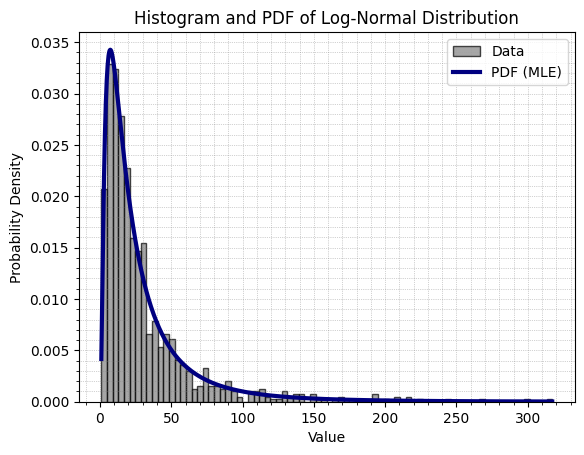

In [4]:
# Plot histogram of the data
plt.hist(data, bins=80, density=True, alpha=0.7, color='gray', edgecolor='black', label='Data')

# Calculate PDF values using MLE estimates
x = np.linspace(min(data), max(data), 1000)
pdf_values = lognorm.pdf(x, np.sqrt(sigma_hat_squared), scale=np.exp(mu_hat))

# Plot PDF
plt.plot(x, pdf_values, 'navy', lw=3, label='PDF (MLE)')

plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Histogram and PDF of Log-Normal Distribution')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.show()

### Part (e)

The expressions for derivatives used in this part are obtained from part (c).
\begin{align*}
    \frac{\partial l}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^{n} \left[\ln{(x_i)} - \mu\right] 
\end{align*}

\begin{align*}
    \frac{\partial l}{\partial (\sigma^2)} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^{n} \left[\ln{(x_i)} - \mu\right]^2
\end{align*}
For calcualtion of derivatives of negative log likelihood, we have to put a negative sign in front of these expressions.

In [5]:
# Define the negative log-likelihood function
def neg_log_likelihood(params, data):
    mu, sigma_sq = params
    n = len(data)
    return (n/2)*np.log(2*np.pi) + (n/2)*np.log(sigma_sq)+ (1/(2*sigma_sq))*np.sum((np.log(data) - mu)**2) - np.sum(np.log(data))

# Calculate the gradient of the negative log-likelihood function
def neg_log_likelihood_gradient(params, data):
    mu, sigma_sq = params
    n = len(data)
    d_mu = np.sum((mu - np.log(data)) / sigma_sq)
    d_sigma_sq = n/(2*sigma_sq) - (1/(2*(sigma_sq)**2))*np.sum((np.log(data)-mu)**2)
    return np.array([d_mu, d_sigma_sq])


To implement the following gradient descent algorithm, I have used pseudo-code from Dr. Chipilski's notes in Data Assimilation course.

In [6]:
# Gradient descent optimization
def gradient_descent(data, theta_0, alpha, max_iter=1000, tol=1e-6):
    """---------------------------------------------------------------------------------------
    Perform gradient descent optimization to minimize the negative log-likelihood function.
    
    Parameters:
    - data     : The data to fit the model to.
    - theta_0  : The initial values for the parameters (mu, sigma^2).
    - alpha    : The learning rate/direction for gradient descent.
    - max_iter : The maximum number of iterations. Default is 1000.
    - tol      : The tolerance for convergence. Default is 1e-6.
    
    Returns:
    - mu_values                 : The values of the parameter mu over iterations.
    - sigma_sq_values           : The values of the parameter sigma^2 over iterations.
    - neg_log_likelihood_values : The values of the negative log-likelihood function.
    - num_iterations            : The number of iterations performed for convergence.
    ----------------------------------------------------------------------------------------"""
    
    theta = theta_0
    neg_log_likelihood_values = []
    mu_values = []
    sigma_sq_values = []
    
    for i in range(max_iter):
        
        # Compute the negative log-likelihood value
        neg_log_likelihood_value = neg_log_likelihood(theta, data)
        neg_log_likelihood_values.append(neg_log_likelihood_value)
        
        # storing current parameter values
        mu_values.append(theta[0])
        sigma_sq_values.append(theta[1])
        
        # computing gradients 
        gradient = neg_log_likelihood_gradient(theta, data)
        
        # updating parameters
        theta_new = theta - alpha * gradient
        
        # checking for convergence using norm
        if np.linalg.norm(theta_new - theta) < tol:
            break
        
        # updating parameters for next iteration
        theta = theta_new
    
    return np.array(mu_values), np.array(sigma_sq_values), neg_log_likelihood_values, i+1

In [7]:
# Given initial values and step size
mu_0 = 10
sigma_sq_0 = 5
alpha = 0.001

# Run gradient descent optimization
theta_0 = np.array([mu_0, sigma_sq_0])
mu_values, sigma_sq_values, neg_log_likelihood_values, iterations = gradient_descent(data, theta_0, alpha)

# Print the number of iterations for convergence
print("----------------------------")
print("         RESULTS ")
print("----------------------------")
print("Iterations:", iterations)
print("mu: {:.5f}".format(mu_values[-1]))
print("sigma: {:.5f}".format(sigma_sq_values[-1]))
print("----------------------------")

----------------------------
         RESULTS 
----------------------------
Iterations: 89
mu: 2.95474
sigma: 0.97424
----------------------------


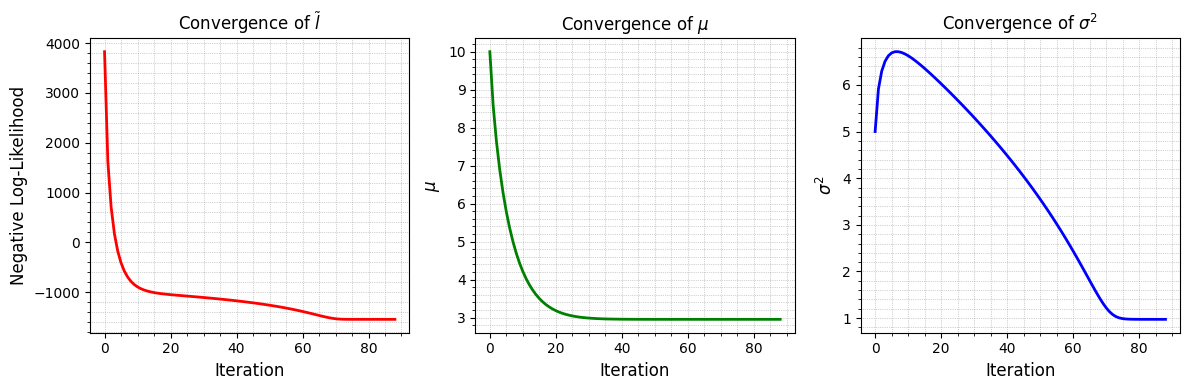

In [8]:
# Plottingh the values of l, mu and sigma^2
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(range(len(neg_log_likelihood_values)), neg_log_likelihood_values, 'red', lw=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Negative Log-Likelihood', fontsize=12)
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Convergence of $\widetilde{l}$')

plt.subplot(1, 3, 2)
plt.plot(range(len(mu_values)), mu_values, 'green', lw=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('$\mu$', fontsize=12)
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Convergence of $\mu$')

plt.subplot(1, 3, 3)
plt.plot(range(len(sigma_sq_values)), sigma_sq_values, 'blue', lw=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('$\sigma^2$', fontsize=12)
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.title('Convergence of $\sigma^2$')

plt.tight_layout()
plt.show()

It takes 89 iterations to converge to the analytical MLE estimates calculated in part (d). As shown in figures, ${l}$ and $\mu$ converges smoothly from their initial guesses. However, $\sigma^2$ first deviates and starts increasing and then decreases to converged value. This might be because of suboptimal initial guess of direction. Also, the convergence depend greatly on initial values and step-size $\alpha$. For good initial guesses (like in this case), the solution will converge in lesser number of iterations. 